# Analysis — What Do the Top 10% Most Popular Spotify Songs Have in Common?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("../data/processed/spotify_cleaned.csv")
print("Loaded successfully!")
print(df.shape)

Loaded successfully!
(49999, 23)


In [2]:
# Define top 10% popularity threshold
threshold = df['popularity'].quantile(0.90)
print(f"Top 10% popularity threshold: {threshold}")

# Split into top 10% and the rest
top10 = df[df['popularity'] >= threshold]
rest  = df[df['popularity'] < threshold]

print(f"Top 10% songs: {len(top10)}")
print(f"Rest of songs: {len(rest)}")

Top 10% popularity threshold: 62.0
Top 10% songs: 5453
Rest of songs: 44546


In [3]:
# Compare average audio features between top 10% and the rest
features = ['danceability', 'energy', 'loudness', 
            'speechiness', 'acousticness', 'valence', 
            'tempo', 'instrumentalness']

comparison = pd.DataFrame({
    'top_10_percent': top10[features].mean(),
    'rest':           rest[features].mean()
})

comparison['difference'] = comparison['top_10_percent'] - comparison['rest']
print(comparison.round(3))

                  top_10_percent     rest  difference
danceability               0.597    0.562       0.034
energy                     0.657    0.640       0.017
loudness                  -7.261   -8.367       1.107
speechiness                0.077    0.085      -0.008
acousticness               0.254    0.321      -0.066
valence                    0.486    0.472       0.014
tempo                    120.733  122.392      -1.660
instrumentalness           0.063    0.167      -0.104


In [4]:
# What percentage of top 10% songs are explicit?
top10_explicit = top10['explicit'].mean() * 100
rest_explicit  = rest['explicit'].mean() * 100

print(f"Explicit in top 10%: {top10_explicit:.1f}%")
print(f"Explicit in rest:    {rest_explicit:.1f}%")

Explicit in top 10%: 13.4%
Explicit in rest:    7.8%


In [5]:
# Which genres dominate the top 10%?
top_genres = top10['track_genre'].value_counts().head(10)
print("Top 10 genres in the top 10% most popular songs:")
print(top_genres)

Top 10 genres in the top 10% most popular songs:
track_genre
pop          280
k-pop        204
metal        197
electro      181
house        177
pop-film     165
edm          165
hard-rock    146
indie-pop    145
grunge       125
Name: count, dtype: int64


In [6]:
# What tempo category do top 10% songs fall into?
print("Tempo category distribution in top 10%:")
print(top10['tempo_category'].value_counts())
print()
print("Tempo category distribution in rest:")
print(rest['tempo_category'].value_counts())

Tempo category distribution in top 10%:
tempo_category
medium    2944
fast      1784
slow       725
Name: count, dtype: int64

Tempo category distribution in rest:
tempo_category
medium    21537
fast      16534
slow       6475
Name: count, dtype: int64


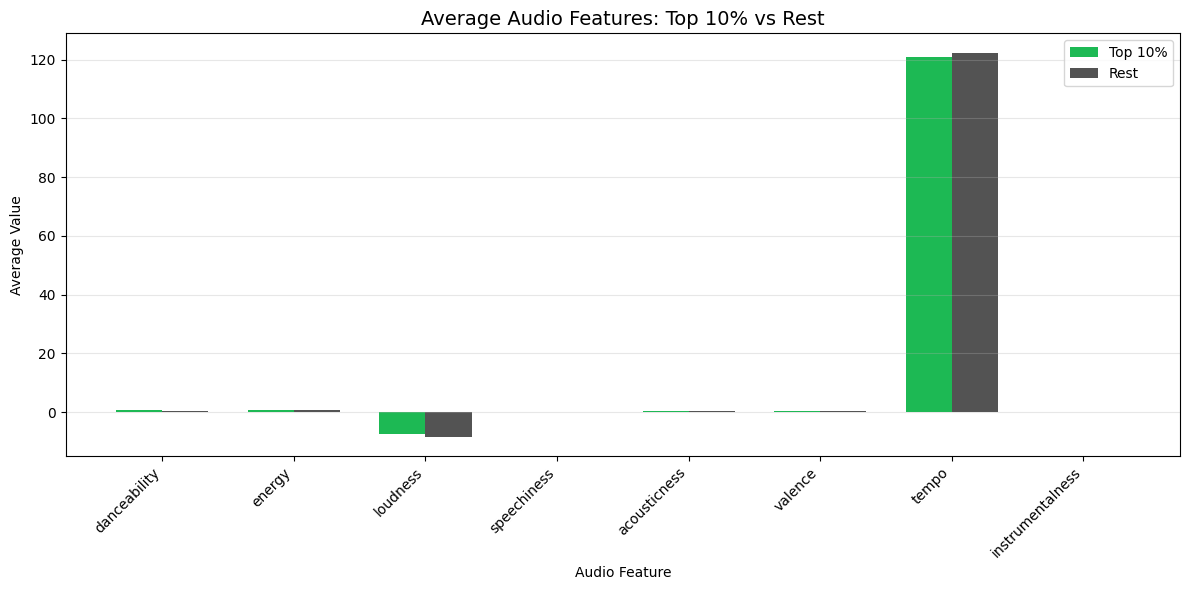

Figure saved!


In [7]:
# Bar chart — average audio features comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(features))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['top_10_percent'], 
               width, label='Top 10%', color='#1DB954')
bars2 = ax.bar(x + width/2, comparison['rest'], 
               width, label='Rest', color='#535353')

ax.set_title('Average Audio Features: Top 10% vs Rest', fontsize=14)
ax.set_xlabel('Audio Feature')
ax.set_ylabel('Average Value')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig("../figures/top10_vs_rest_features.png", dpi=300)
plt.show()
print("Figure saved!")

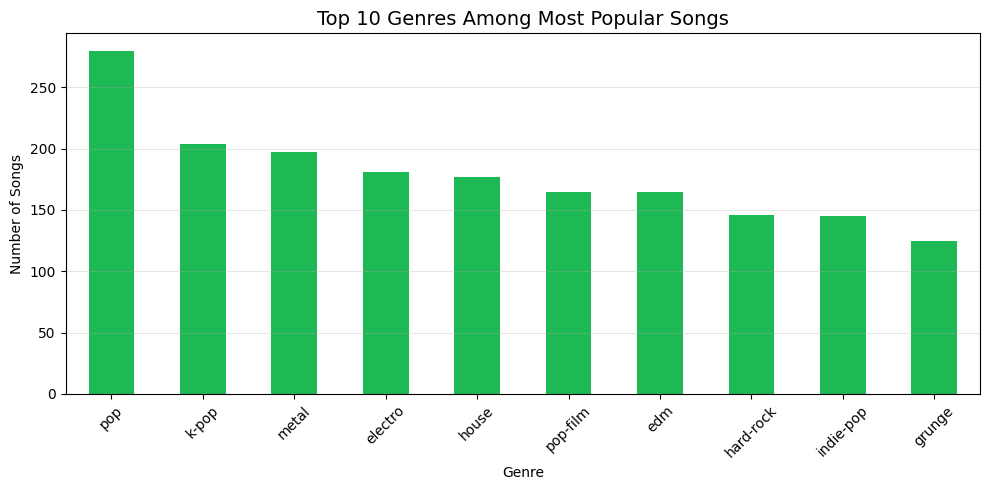

Figure saved!


In [8]:
# Bar chart — top genres in top 10%
fig, ax = plt.subplots(figsize=(10, 5))

top_genres.plot(kind='bar', ax=ax, color='#1DB954')

ax.set_title('Top 10 Genres Among Most Popular Songs', fontsize=14)
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Songs')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig("../figures/top10_genres.png", dpi=300)
plt.show()
print("Figure saved!")

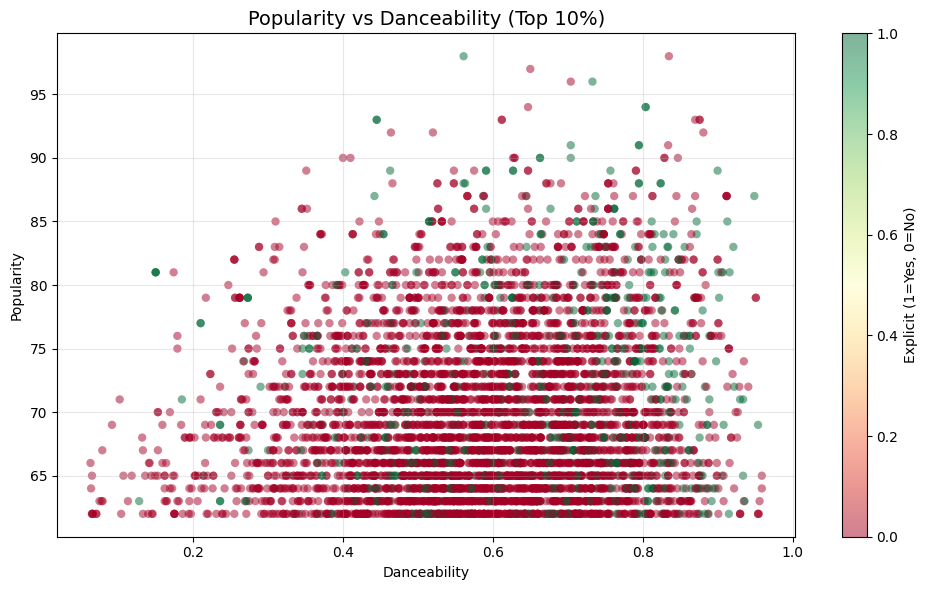

Figure saved!


In [9]:
# Scatter plot — popularity vs danceability colored by explicit
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    top10['danceability'],
    top10['popularity'],
    c=top10['explicit'],
    cmap='RdYlGn',
    alpha=0.5,
    edgecolors='none'
)

ax.set_title('Popularity vs Danceability (Top 10%)', fontsize=14)
ax.set_xlabel('Danceability')
ax.set_ylabel('Popularity')
plt.colorbar(scatter, label='Explicit (1=Yes, 0=No)')
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("../figures/top10_popularity_danceability.png", dpi=300)
plt.show()
print("Figure saved!")

## Key Findings — What Do Top 10% Most Popular Spotify Songs Have in Common?

### Audio Features
- Top 10% songs have **higher danceability** than the rest
- Top 10% songs tend to be **less instrumental** — more vocal/lyric driven
- Top 10% songs are slightly **louder** on average
- **Valence (happiness)** is slightly higher in popular songs

### Explicit Content
- **13.4%** of top 10% songs are explicit
- vs **7.8%** in the rest of songs
- Explicit songs are **almost twice as likely** to appear in the top 10%
- This suggests explicit content does correlate with higher popularity

### Genres
- The most popular genres are **pop, k-pop, and metal**
- Pop dominates with 280 songs, followed by k-pop (204) and metal (197)
- EDM, house, and electro also appear strongly — energy-driven genres perform well
- Indie-pop and grunge also make the top 10 — diverse taste in popular music

### Tempo
- Most popular songs fall in the **medium tempo** range (90-130 BPM)
- **54%** of top 10% songs are medium tempo
- Only **13%** are slow tempo — slow songs rarely hit the top

### Conclusion
The "formula" for a popular Spotify song appears to be:
- ✅ High danceability
- ✅ Moderate to high energy
- ✅ Low instrumentalness — vocal/lyric driven songs do better
- ✅ Medium tempo (90-130 BPM)
- ✅ Belongs to **pop, k-pop, metal, or EDM** genres
- ✅ Slightly more likely to be explicit